In [3]:
import torch
from torch.distributions import Dirichlet, Categorical, Normal
import matplotlib.pyplot as plt
import matplotlib as mpl
import mpltern
import numpy as np
import pandas as pd

# Create synthetic classification dataset

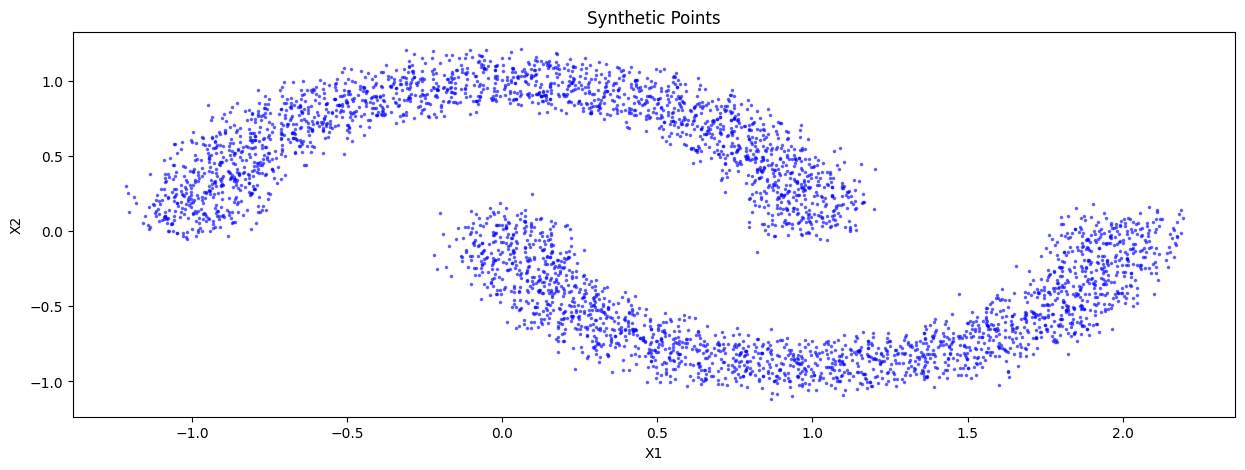

In [4]:
def generate_moon(n_samples=500, radius=1.0, width=0.3, distance=0.1, noise=0.05, flip=False):
    angles = np.linspace(0, np.pi, n_samples)
    r = radius + width * (np.random.rand(n_samples) - 0.5)
    x = r * np.cos(angles)
    y = r * np.sin(angles)

    if flip:
        x = -x + radius  # flip and shift right
        y = -y + distance  # shift down

    x += np.random.normal(0, noise, n_samples)
    y += np.random.normal(0, noise, n_samples)

    x = torch.from_numpy(x).float()
    y = torch.from_numpy(y).float()
    return torch.column_stack([x,y])






def generate_x_points(n_samples=1000):
    """
    Generate n_samples points in the simplex.
    """
    # Generate random points in the simplex
    # Generate both moons
    moon1 = generate_moon(n_samples)
    moon2= generate_moon(n_samples,flip=True)
    points = torch.concatenate([moon1, moon2], dim=0).numpy()
    return points

# visualize the points
def visualize_points(points):
    """
    Visualize the points in the simplex.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    ax.scatter(points[:,0], points[:,1], marker='.', s=10, alpha=0.5, color='blue')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.show()

# Generate points
point_bunch = generate_x_points()
point_bunch2 = generate_x_points()
points = np.concatenate((point_bunch,point_bunch2),axis=0).astype(np.float32)
# Visualize points
visualize_points(points)

# Define True Target Probability Distribution

In [5]:
# define 1st order probability distribution

def generate_y_probs(points):
    # Parameters for moons
    r = 1.0
    center0 = torch.tensor(np.array([0, 0],dtype=float))       # First moon
    center1 = torch.tensor(np.array([1, 0.5], dtype=float))     # Second moon (flipped and shifted)

    # Convert to polar coordinates relative to each moon
    rel0 = points - center0
    rel1 = points - center1

    theta0 = torch.arctan2(rel0[:,1], rel0[:,0])
    theta1 = torch.arctan2(-rel1[:,1], rel1[:,0])  # flipped second moon

    r0 = torch.linalg.norm(rel0, dim=1)
    r1 = torch.linalg.norm(rel1, dim=1)

    # Mask angles: first moon lives in [0, pi], second in [0, pi] after flip
    arc0 = (theta0 >= 0) & (theta0 <= np.pi)
    arc1 = (theta1 >= 0) & (theta1 <= np.pi)

    # Score proximity to moon arcs (lower deviation → higher probability)
    score0 = arc0 * (1 - torch.abs(r0 - r))  # closer to radius 1
    score1 = arc1 * (1 - torch.abs(r1 - r))

    # Decision value
    z = score0 - score1

    # Sigmoid probability
    probs = 1 / (1 + torch.exp(-z))  # sharper boundary with higher factor
    y_probs = torch.stack([1-probs, probs], dim=-1)
    return y_probs.clip(1e-8,(9999999)/1e7)

def generate_target_and_probs(points):
    y_probs = generate_y_probs(points)
    y_labels = torch.argmax(y_probs, dim=1)
    return y_labels, y_probs

y_labels, y_probs = generate_target_and_probs(torch.tensor(points))
y_probs

tensor([[0.4175, 0.5825],
        [0.6592, 0.3408],
        [0.3853, 0.6147],
        ...,
        [0.6962, 0.3038],
        [0.7210, 0.2790],
        [0.7148, 0.2852]], dtype=torch.float64)

# Define Ensemble

In [6]:
ENSEMBLE_MEMBER_COUNT = 10


# define (mimic) ensemble
def noisy_probability(points,generator):
    y_probs = generate_y_probs(points)
    noise = 0.01*torch.randn(y_probs.size(),
                        generator=generator,
                        dtype=y_probs.dtype,
                        layout=y_probs.layout,
                        device=y_probs.device)
    y_probs_noisy = torch.logit(y_probs).add(noise).softmax(dim=-1)
    return y_probs_noisy
def ensemble_probs(points):
    y_probs_ensemble = torch.stack([noisy_probability(points,
                                                      torch.Generator().manual_seed(i)
                                                      ) for i in range(ENSEMBLE_MEMBER_COUNT)])
    return y_probs_ensemble

def ensemble_preditions(points):
    y_probs_ensemble = ensemble_probs(points)
    return y_probs_ensemble.mean(dim=0).argmax(dim=1)
y_probs_ensemble_points = ensemble_probs(torch.tensor(points))
y_pred_ensemble_points = ensemble_preditions(torch.tensor(points))
y_pred_ensemble_points
ensemble_probs(torch.tensor([[10,10]]))

tensor([[[1.0000e+00, 2.7894e-11]],

        [[1.0000e+00, 2.8298e-11]],

        [[1.0000e+00, 2.8236e-11]],

        [[1.0000e+00, 2.8232e-11]],

        [[1.0000e+00, 2.8937e-11]],

        [[1.0000e+00, 2.8377e-11]],

        [[1.0000e+00, 2.8662e-11]],

        [[1.0000e+00, 2.8677e-11]],

        [[1.0000e+00, 2.7975e-11]],

        [[1.0000e+00, 2.8946e-11]]], dtype=torch.float64)

In [7]:
def total_uncertainty_ensemble(y_probs_ensemble):
    y_probs_mean = y_probs_ensemble.mean(dim=0)
    return y_probs_mean.mul(y_probs_mean.log2()).sum(dim=-1).mul(-1)

def aleatoric_uncertainty_ensemble(y_probs_ensemble):
    return y_probs_ensemble.mul(y_probs_ensemble.log2()).sum(dim=-1).mul(-1).mean(dim=0)

def epistemic_uncertainty_ensemble(y_probs_ensemble):
    return (total_uncertainty_ensemble(y_probs_ensemble) - aleatoric_uncertainty_ensemble(y_probs_ensemble)).clip(0,1)


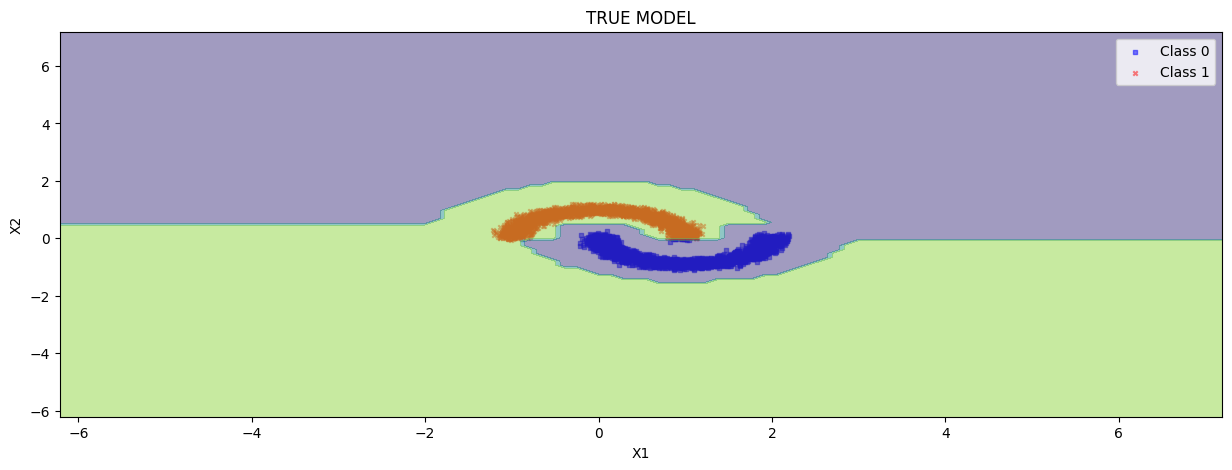

In [8]:
# visualize the labels distribution for the points
def visualize_labels_distribution(points,y_labels):
     # Create gird of points
    grid_points = np.linspace(points.min()-5, points.max()+5, 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    grid_y_labels,_ = generate_target_and_probs(torch.tensor(grid_points))
    gird_y_labels = grid_y_labels.numpy()

    # Plot the points
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # Plot TU
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.contourf(xx, yy, grid_y_labels.reshape(xx.shape),levels=2, alpha=0.5)
    ax.set_title("TRUE MODEL")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    plt.legend()
    plt.show()

visualize_labels_distribution(points,y_labels)

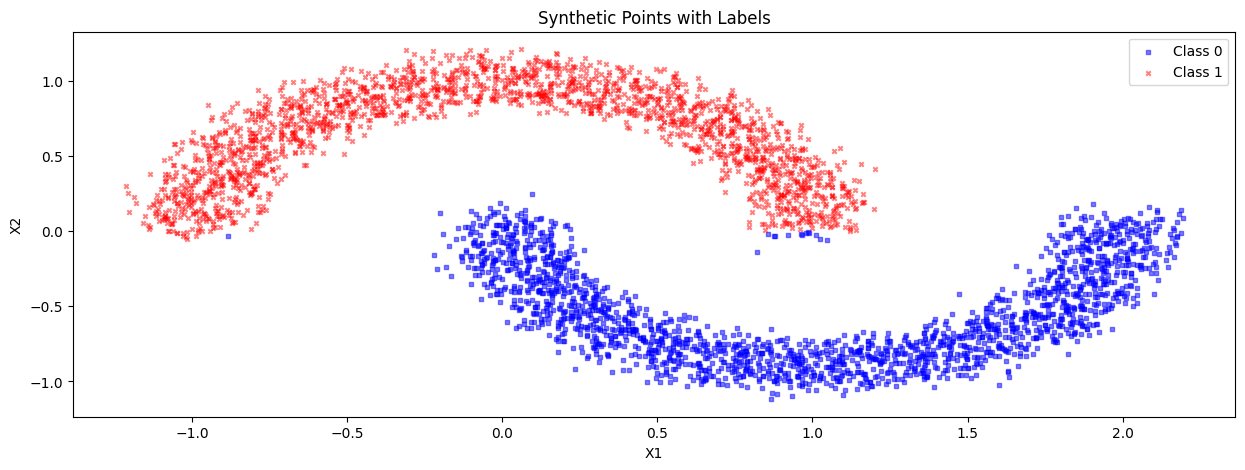

In [9]:
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()

# Visualize points and labels
visualize_points_and_labels(points, y_labels)

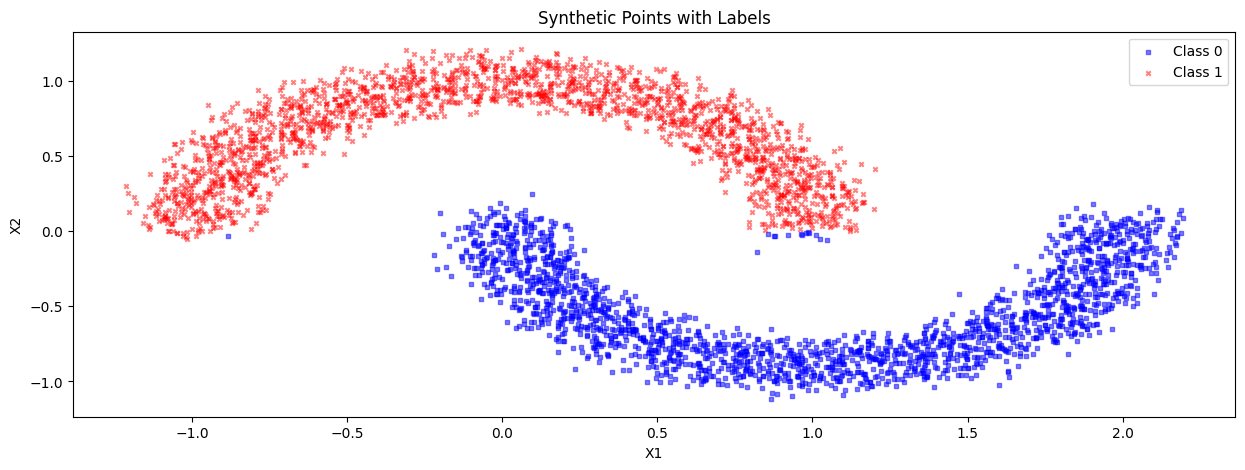

In [10]:
# visualize predictions of the ensemble
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()


# Visualize points and labels
visualize_points_and_labels(points, y_pred_ensemble_points)


tensor(1.2253e-06, dtype=torch.float64) tensor(1.0000, dtype=torch.float64)


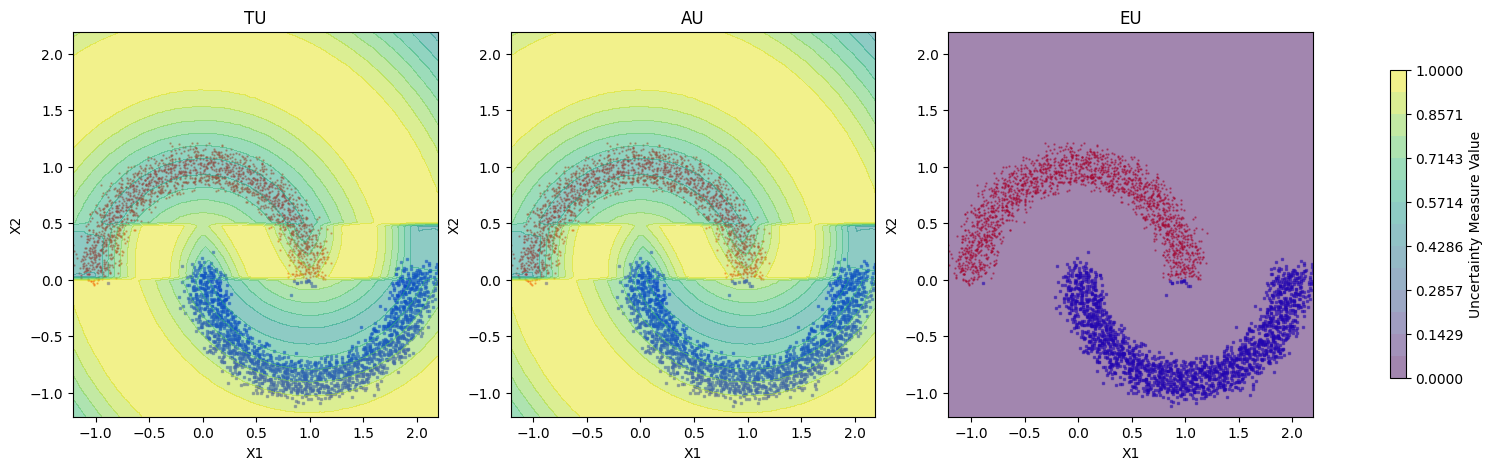

In [11]:
# Look at a given point and AU,EU,TU
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    y_probs_ensemble = ensemble_probs(torch.tensor(grid_points))
    total_uncertainty = total_uncertainty_ensemble(y_probs_ensemble)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(y_probs_ensemble)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(y_probs_ensemble)

    # Shared value range
    all_vals = torch.concatenate([total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, data, title in zip(axes, [total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], ["TU", "AU", "EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='.', s=2, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(points,y_pred_ensemble_points)

# CF construction

In [12]:
MAX_STEPS = 1000
UNCERTAINTY_STEP_INCREASE = 1e-2
DESIRED_VALIDITY = 0.9

### Validity
We now work in the scenario of creating a valid counter factual for our point x

In [13]:
point_of_interest = torch.tensor(np.array([0.2,-0.1]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [14]:
def validity_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    # Get the probs in the start
    probs = ensemble_probs(counter_factual).mean(dim=0)
    target_probs = probs[0,desired_class]
    # Optimization Iteration
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs = ensemble_probs(counter_factual).mean(dim=0)
        target_probs = probs[0,desired_class]
        # Calculate the loss
        loss = -target_probs
        #print(target_probs)
        # Backpropagate
        loss.backward()
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_valid, cf_steps_valid = validity_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

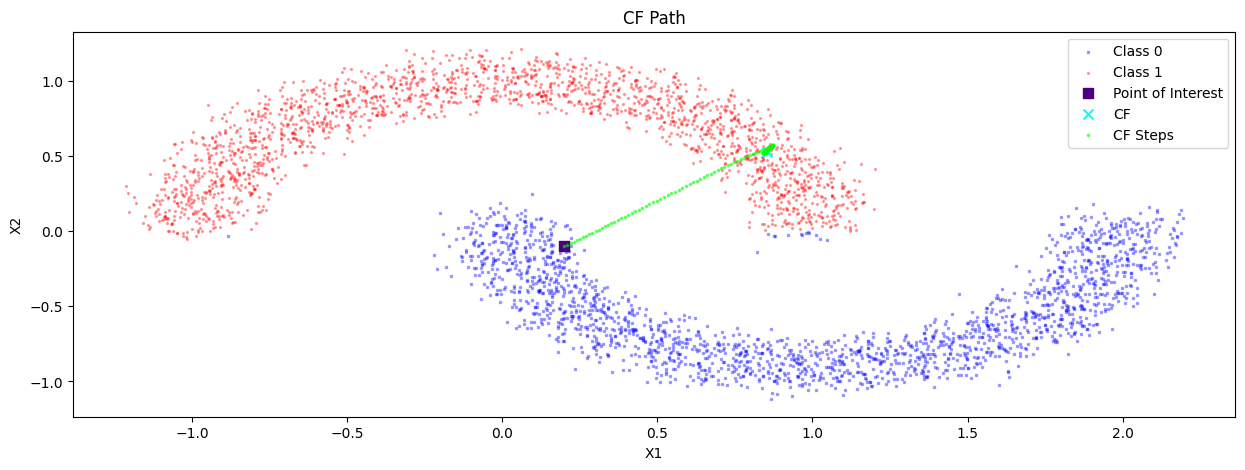

In [15]:
def visualize_cf_and_steps(cf,cf_steps, points, y_labels):
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # visualize the data itself
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.3, color='blue', label='Class 0')
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='o', s=2, alpha=0.3, color='red', label='Class 1')

    ax.scatter(point_of_interest[:,0].detach(), point_of_interest[:,1].detach(), marker='s', s=50, alpha=1, color='indigo', label="Point of Interest")

    ax.scatter(cf[:,0], cf[:,1], marker='x', s=50, color='aqua', label="CF")

    ax.scatter(cf_steps[:,0], cf_steps[:,1], marker='.', s=10, alpha=0.5, color='lime', label="CF Steps")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title("CF Path")

    plt.legend()
visualize_cf_and_steps(cf_valid, cf_steps_valid, points, y_labels)

## Plausability

In [16]:
def plausability_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)


        target_probs = probs[0,desired_class]
        # Calculate the loss
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        loss = (-target_probs).add(t*eu)

        # Backpropagate
        loss.backward()
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_plausable, cf_steps_plausable = plausability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

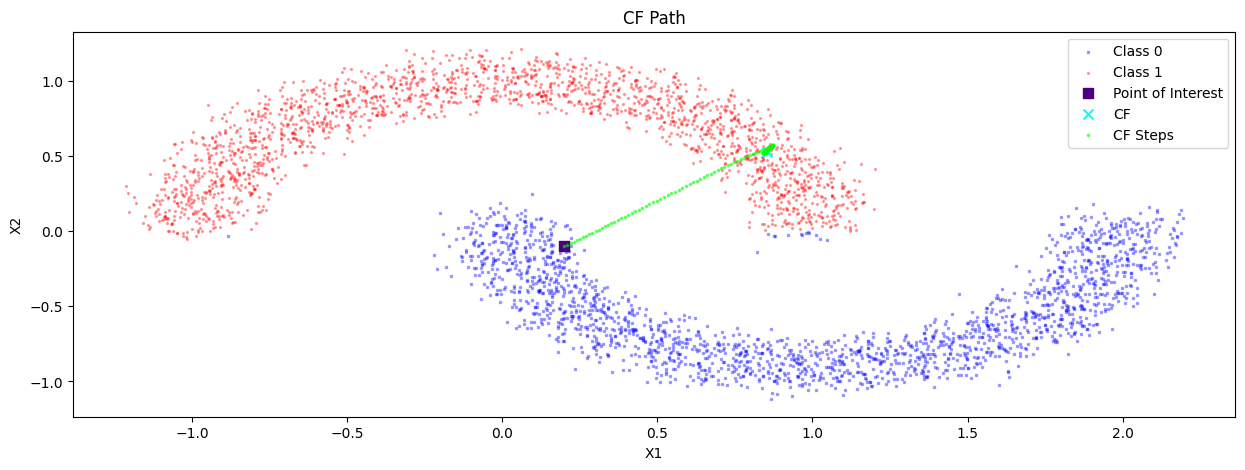

In [17]:
visualize_cf_and_steps(cf_plausable, cf_steps_plausable, points, y_pred_ensemble_points)

In [18]:
cf_plausable, cf_valid

(tensor([[0.8519, 0.5266]]), tensor([[0.8519, 0.5266]]))

In [19]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable)), epistemic_uncertainty_ensemble(ensemble_probs(cf_valid))

(tensor([1.1516e-05], dtype=torch.float64),
 tensor([1.1516e-05], dtype=torch.float64))

## Discrimitiveness

In [20]:
def discriminiative_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = aleatoric_uncertainty_ensemble(probs_ensemble)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual,au, t)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_discriminiative, cf_steps_discriminiative = discriminiative_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

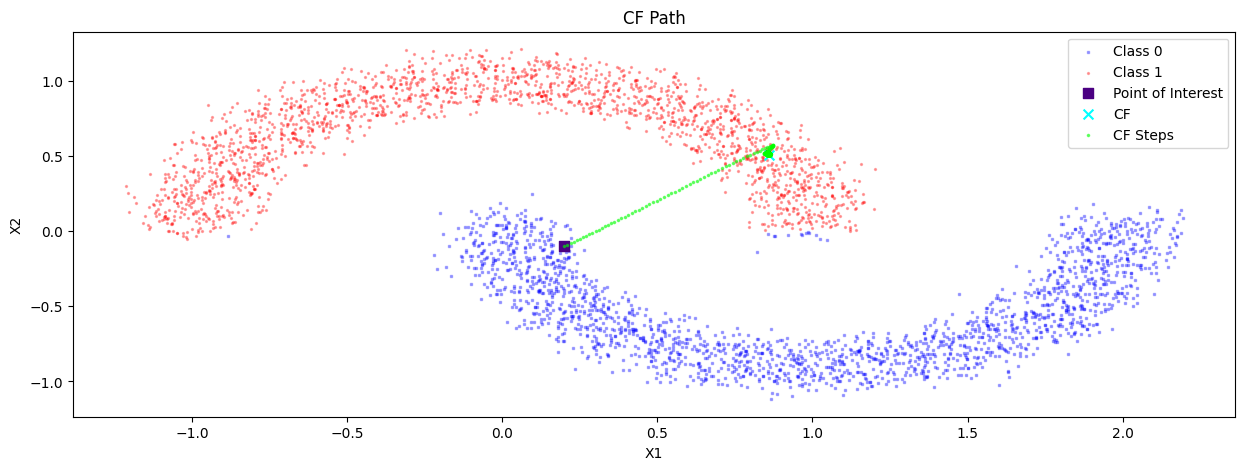

In [21]:
visualize_cf_and_steps(cf_discriminiative, cf_steps_discriminiative, points, y_pred_ensemble_points)


In [22]:
cf_discriminiative, cf_plausable, cf_valid

(tensor([[0.8594, 0.5051]]),
 tensor([[0.8519, 0.5266]]),
 tensor([[0.8519, 0.5266]]))

In [23]:
aleatoric_uncertainty_ensemble(ensemble_probs(cf_plausable)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_valid)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_discriminiative))


(tensor([0.5278], dtype=torch.float64),
 tensor([0.5278], dtype=torch.float64),
 tensor([0.5289], dtype=torch.float64))

## Stability

In [24]:
from sklearn.neighbors import NearestNeighbors


def sample_delta_ball(reference_point, delta, n_points):
    """
    :param point:
    :param delta:
    :param norm:
    :return:
    """
    delta_samples = []
    for _ in range(n_points):
        sample = np.random.randn(*reference_point.shape)
        sample /= np.linalg.norm(sample,ord=2,axis=-1, keepdims=True)**2
        delta_sample = sample  * delta
        delta_samples.append([delta_sample])
    samples = np.concatenate(delta_samples,axis=0)
    delta_samples = (reference_point + samples).astype(np.float32)
    return torch.tensor(delta_samples.reshape(-1,2)).requires_grad_(True)


def get_knn_points(point,k=5):
    knn = NearestNeighbors(n_neighbors=k,algorithm="brute")
    knn.fit(points)
    distances, indices = knn.kneighbors(point.detach().numpy())
    return torch.tensor(points[indices[0]]).requires_grad_(True)


In [25]:
def stable_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -(target_probs_delta_ball.mean()) + ((tu_delta_ball.mean() - tu_delta_ball_start.mean())**2 + (tu_delta_ball.std() -tu_delta_ball_start.std())**2)
        #loss = -(target_probs_delta_ball.mean())

        # Backpropagate
        loss.backward()
        #lam = 0.9
        counter_factual.grad = delta_ball.grad.mean(dim=0,keepdims=True)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_stable, cf_steps_stable = stable_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY,delta=0.2)

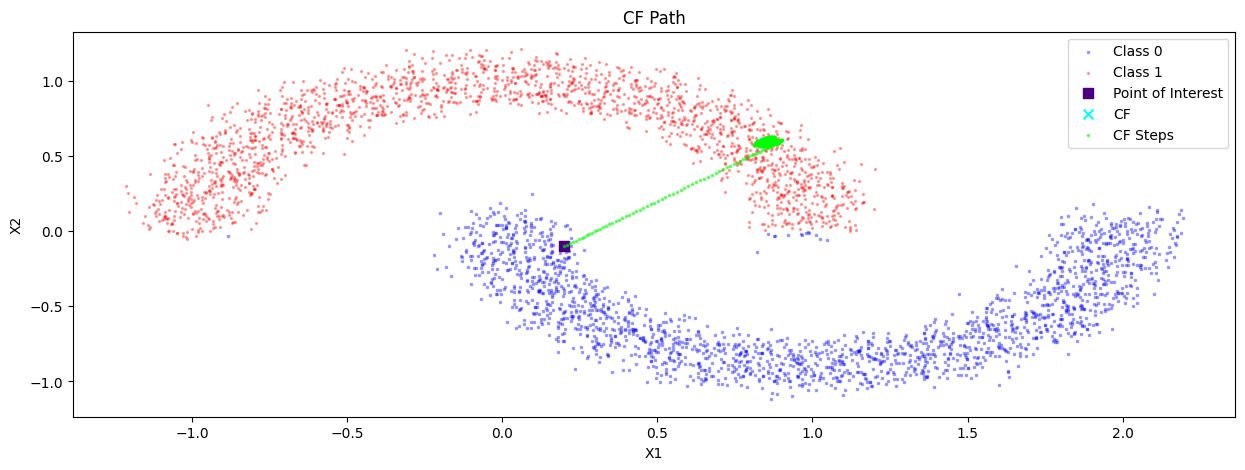

In [26]:
visualize_cf_and_steps(cf_stable,cf_steps_stable, points, y_pred_ensemble_points)

In [27]:
#delta_point_of_interest = sample_delta_ball(point_of_interest.detach().numpy(), delta=0.1, n_points=10)
delta_point_of_interest = get_knn_points(point_of_interest, k=5)
cf_points_stable = []
for point in delta_point_of_interest:
    cf_point, cf_steps_point = stable_procedure(point.view(-1,2), desired_validity=0.9, delta=0.2, n_points=10)
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    cf_points_stable.append(cf_point)

# compare with validitiy procedure
cf_points_not_stable =[]
for point in delta_point_of_interest:
    cf_point, cf_steps_point = validity_procedure(point.view(-1,2), desired_validity=0.9)
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    cf_points_not_stable.append(cf_point)


# compute the mean l2 distance for stable and not stable
l2_distances_stable = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_stable
    for p2 in cf_points_stable
    if (p1 != p2).all()
]
l2_distances_unstable = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_not_stable
    for p2 in cf_points_not_stable
    if (p1 != p2).all()
]

print("Mean L2-Distance of Stable Procedure: ", np.mean(l2_distances_stable), " +/- ",  np.std(l2_distances_stable))
print("Mean L2-Distance of Unstable Procedure: ", np.mean(l2_distances_unstable), " +/- ",  np.std(l2_distances_unstable))

Mean L2-Distance of Stable Procedure:  1.2645010963082313  +/-  1.4996651267879564
Mean L2-Distance of Unstable Procedure:  1.9002569056348875  +/-  2.3155664447610427


In [28]:
cf_points_stable

[tensor([[0.8509, 0.6187]]),
 tensor([[0.8139, 0.6519]]),
 tensor([[0.8302, 0.6516]]),
 tensor([[0.8430, 0.5990]]),
 tensor([[-1.2815, -1.6367]])]

In [29]:
cf_points_not_stable

[tensor([[0.8572, 0.5098]]),
 tensor([[-2.4315, -2.8979]]),
 tensor([[-2.4423, -2.8889]]),
 tensor([[-2.4316, -2.8972]]),
 tensor([[-2.4427, -2.8883]])]

## Sparsisity

In [30]:
def sparse_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -target_probs
        #loss = -(target_probs_delta_ball.mean())

        # Backpropagate
        loss.backward()

        # Update the gradients of delta_ball
        gradients = counter_factual.grad.requires_grad_(True)
        base_gradients = torch.eye(gradients.shape[-1])
        gradients_normalized = torch.nn.functional.normalize(gradients, dim=-1)

        similarity_matrix = torch.matmul(gradients_normalized, base_gradients.T).mean()

        loss2 = -similarity_matrix
        loss2.backward()

        lam = 0.5
        counter_factual.grad = (lam*counter_factual.grad + (1-lam)*gradients.grad).mean(dim=0,keepdim=True)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1

    return counter_factual.detach(), counter_factual_steps

def sparse_procedure_2(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -target_probs
        loss2 = -(target_probs_delta_ball.mean())
        #loss = -(target_probs_delta_ball.mean())

        # Backpropagate
        loss.backward(retain_graph=True)
        loss2.backward(retain_graph=True)

        epsilon = delta_ball.grad.abs().mean() - delta_ball.grad.abs().std()
        bernoulli_prob_sampled =  1 - (abs(delta_ball.grad) <= epsilon).float().mean(dim=0)
        bernoulli_prob_importance = (delta_ball.grad.abs() / delta_ball.grad.abs().sum(dim=1).view(-1,1)).mean(dim=0) # States the proportion each dimension does to the total change



        bernoulli_variable = torch.bernoulli(bernoulli_prob_importance)

        counter_factual.grad = bernoulli_variable * counter_factual.grad
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1

    return counter_factual.detach(), counter_factual_steps

def sparse_procedure_3(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    bernoulli_prob_importance = torch.zeros(counter_factual.shape)
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -target_probs
        loss2 = -(target_probs_delta_ball.mean())

        # Backpropagate
        loss.backward(retain_graph=True)
        loss2.backward(retain_graph=True)
        most_magnitude_feature_change = delta_ball.grad.abs().mean(dim=0).argmax()
        bernoulli_prob_importance[0,most_magnitude_feature_change] += 1

        bernoulli_variable = torch.bernoulli(bernoulli_prob_importance.div(bernoulli_prob_importance.sum()))

        counter_factual.grad = bernoulli_variable * counter_factual.grad
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1

    return counter_factual.detach(), counter_factual_steps

def sparse_procedure_4(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    bernoulli_prob_importance = torch.zeros(counter_factual.shape)
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -target_probs + 0.2*torch.linalg.norm(counter_factual - point_of_interest, ord=1)

        # Backpropagate
        loss.backward(retain_graph=True)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1

    return counter_factual.detach(), counter_factual_steps

cf_sparse, cf_sparse_steps = sparse_procedure_3(point_of_interest,desired_validity=DESIRED_VALIDITY,delta=0.2)
cf_sparse2, cf_sparse_steps2 = sparse_procedure_4(point_of_interest, desired_validity=DESIRED_VALIDITY,delta=0.2)

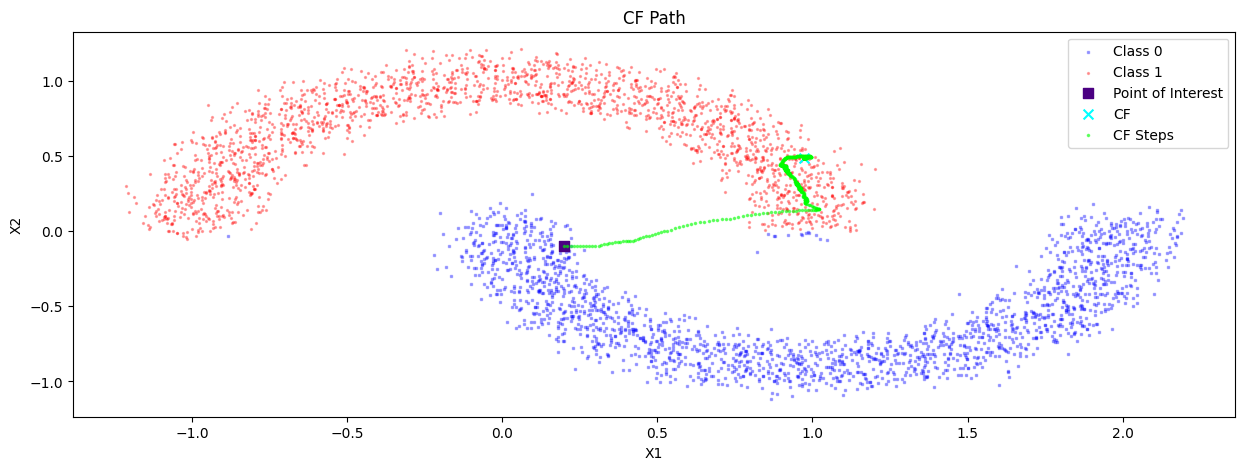

In [31]:
visualize_cf_and_steps(cf_sparse, cf_sparse_steps, points, y_pred_ensemble_points)

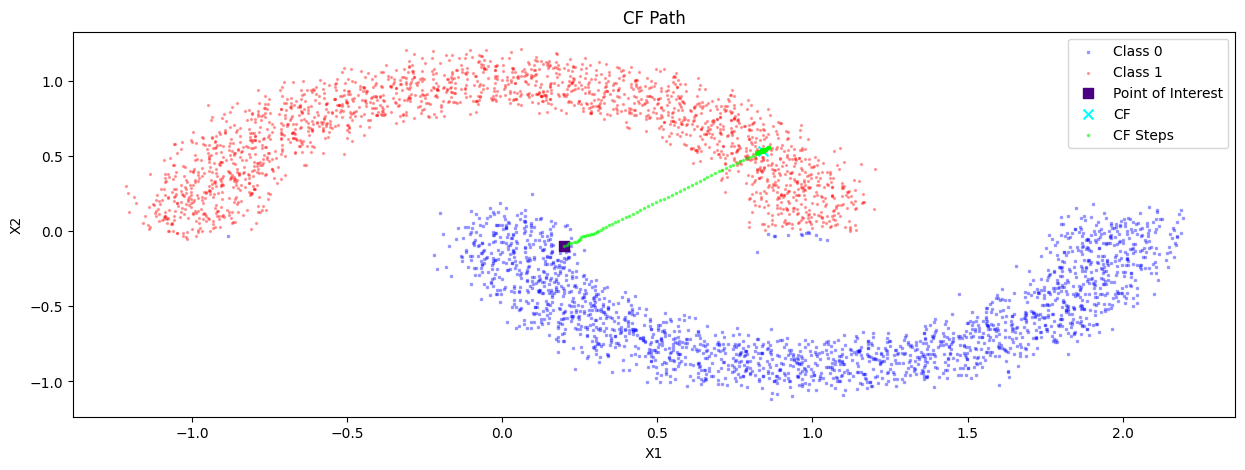

In [32]:
visualize_cf_and_steps(cf_sparse2, cf_sparse_steps2, points, y_pred_ensemble_points)


In [33]:
# Check how sparse the point is in contrast to validity
diff_valids = []
diff_sparse = []
diff_sparse2 = []
cf_valid, _ = validity_procedure(point_of_interest, desired_validity=0.9)
for _ in range(10):
    cf_sparse,_ = sparse_procedure_3(point_of_interest,desired_validity=0.9, delta=0.2)
    cf_sparse2,_ = sparse_procedure_4(point_of_interest, desired_validity=0.9)
    diff_v = torch.norm(cf_valid - point_of_interest, p=1).item()
    diff_s = torch.norm(cf_sparse - point_of_interest, p=1).item()
    diff_s2 = torch.norm(cf_sparse2 - point_of_interest, p=1).item()
    diff_valids.append(diff_v)
    diff_sparse.append(diff_s)
    diff_sparse2.append(diff_s2)
print(f"Valid Diff: {np.mean(diff_valids)} +/- {np.std(diff_valids)}")
print(f"Sparse Diff: {np.mean(diff_sparse)} +/- {np.std(diff_sparse)}")
print(f"Sparse Diff: {np.mean(diff_sparse2)} +/- {np.std(diff_sparse2)}")

Valid Diff: 1.2784152030944824 +/- 0.0
Sparse Diff: 1.2723624944686889 +/- 0.022120288626035857
Sparse Diff: 1.276973009109497 +/- 0.0


In [34]:
delta_point_of_interest = sample_delta_ball(point_of_interest.detach().numpy(), delta=1, n_points=10)
for point in delta_point_of_interest:
    # Check how sparse the point is in contrast to validity
    diff_valids = []
    diff_sparse = []
    cf_valid, _ = validity_procedure(point.view(-1,2), desired_validity=0.9)
    for _ in range(10):
        cf_sparse,_ = sparse_procedure_3(point.view(-1,2),desired_validity=0.9)

        diff_v = torch.norm(cf_valid - point_of_interest, p=1).item()
        diff_s = torch.norm(cf_sparse - point_of_interest, p=1).item()
        diff_valids.append(diff_v)
        diff_sparse.append(diff_s)
    print(f"Valid Diff: {np.mean(diff_valids)} +/- {np.std(diff_valids)}")
    print(f"Sparse Diff: {np.mean(diff_sparse)} +/- {np.std(diff_sparse)}")

Valid Diff: 5.449195861816406 +/- 0.0
Sparse Diff: 4.80722713470459 +/- 0.11606826846026135
Valid Diff: 5.481098175048828 +/- 0.0
Sparse Diff: 4.443581867218017 +/- 0.06954340284940884
Valid Diff: 1.3169318437576294 +/- 0.0
Sparse Diff: 1.3038119673728943 +/- 0.01689777615968439
Valid Diff: 1.2851495742797852 +/- 0.0
Sparse Diff: 1.2296737432479858 +/- 0.07683161548763774
Valid Diff: 7.1619181632995605 +/- 0.0
Sparse Diff: 5.507128763198852 +/- 0.238764250755017
Valid Diff: 1.2771509885787964 +/- 0.0
Sparse Diff: 1.3006890058517455 +/- 0.012658080048672266
Valid Diff: 1.3118717670440674 +/- 0.0
Sparse Diff: 1.2866206407546996 +/- 0.03589306629868542
Valid Diff: 5.454407691955566 +/- 0.0
Sparse Diff: 4.335039663314819 +/- 0.07698137699460679
Valid Diff: 1.3137497901916504 +/- 0.0
Sparse Diff: 1.2794615626335144 +/- 0.049665006369736794
Valid Diff: 5.43402099609375 +/- 0.0
Sparse Diff: 4.939286851882935 +/- 0.1216646018228315


 ## Robustness

tensor(6.1400e-06, dtype=torch.float64, grad_fn=<MinBackward1>) tensor(5.1070e-05, dtype=torch.float64, grad_fn=<MaxBackward1>)


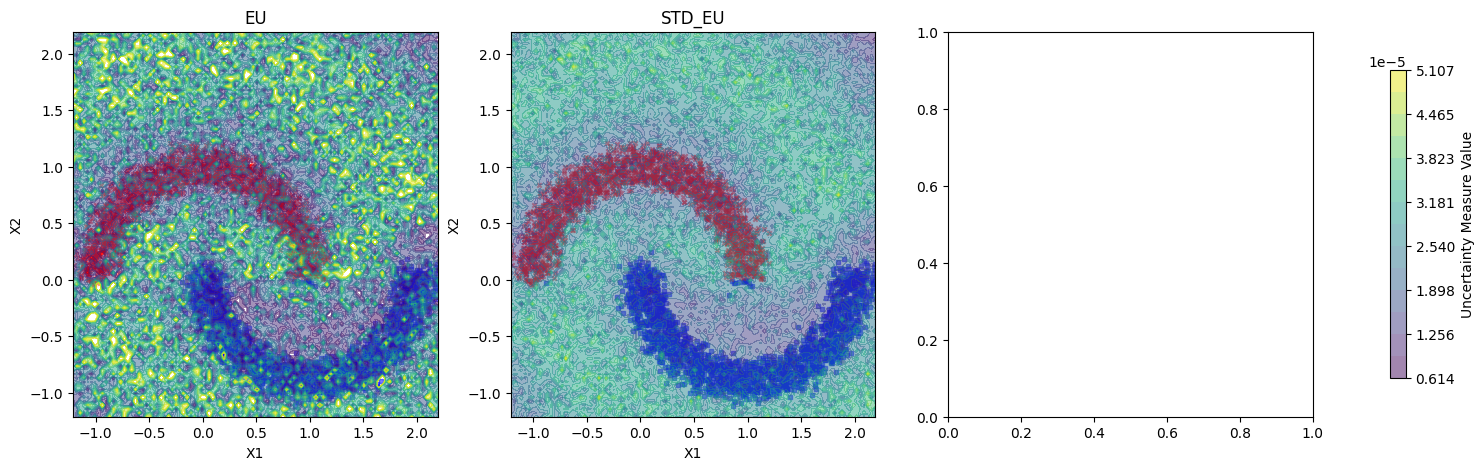

In [35]:
# visualize how std of eu looks like aroung the points
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),0.2,10)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).view(10,-1)


    std_eu_ball = torch.mean(torch.cat((eu_delta_ball,epistemic_uncertainty.view(1,-1))),dim=0)

    # Shared value range
    all_vals = torch.concatenate([std_eu_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, data, title in zip(axes, [epistemic_uncertainty, std_eu_ball], ["EU","STD_EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(points,y_pred_ensemble_points)

In [36]:
def robust_procedure(point_to_explain, desired_validity=0.8, delta=0.2, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points).view(-1,2)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]

        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        std_eu_ball = torch.std(
            eu_delta_ball
        )**2
        mean_eu_ball = torch.mean(
            eu_delta_ball
        )
        # Calculate the loss
        loss = (-target_probs + (t*std_eu_ball))

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual,eu,std_eu_ball,mean_eu_ball, t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_robust, cf_steps_robust = robust_procedure(point_of_interest,delta=0.5)

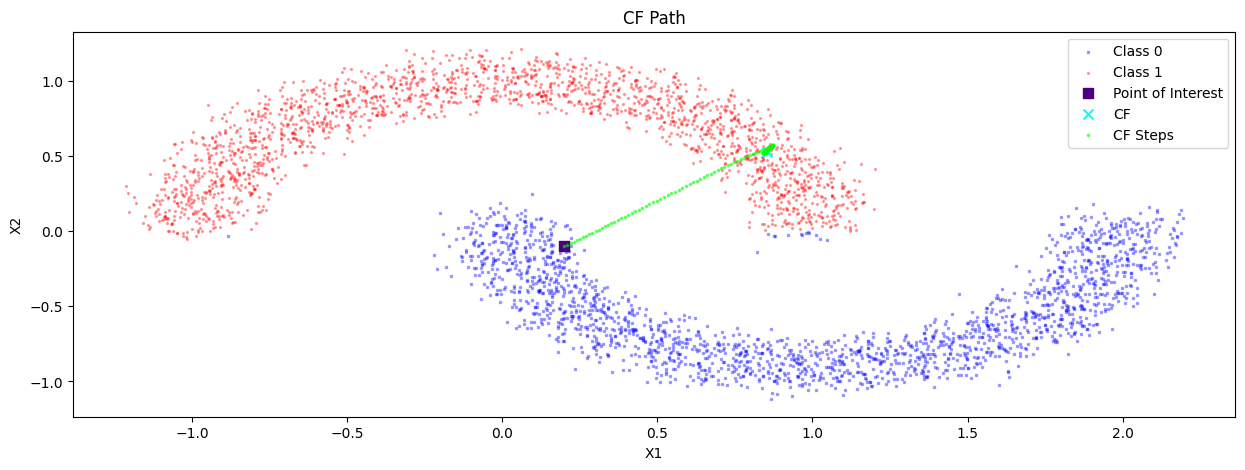

In [37]:
visualize_cf_and_steps(cf_robust,cf_steps_robust, points, y_pred_ensemble_points)

In [38]:
cf_robust, cf_plausable

(tensor([[0.8519, 0.5266]]), tensor([[0.8519, 0.5266]]))

In [39]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_robust)), epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable))

(tensor([1.1516e-05], dtype=torch.float64),
 tensor([1.1516e-05], dtype=torch.float64))

In [40]:

res_mean = []
res_std = []
for _ in range(10):
    delta_cf_robust = sample_delta_ball(cf_robust.detach().numpy(), delta=1, n_points=100)
    epistemic_cf_robust = []
    for point in delta_cf_robust:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_robust.append(
            epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
        )

    delta_cf_plausable = sample_delta_ball(cf_plausable.detach().numpy(), delta=1, n_points=100)
    epistemic_cf_plausable = []
    for point in delta_cf_plausable:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_plausable.append(
            epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
        )

    print("Std Epistemic Uncertainty of Robust Procedure: ",np.mean(epistemic_cf_robust) , " +/- " ,  np.std(epistemic_cf_robust))
    print("Std Epistemic Uncertainty of Plausable Procedure: ", np.mean(epistemic_cf_plausable) , " +/- " , np.std(epistemic_cf_plausable))

    res_mean.append([np.mean(epistemic_cf_robust), np.mean(epistemic_cf_plausable)])
    res_std.append([np.std(epistemic_cf_robust), np.std(epistemic_cf_plausable)])

np.mean(res_mean,axis=0), np.std(res_mean,axis=0), np.mean(res_std,axis=0), np.std(res_std,axis=0)

Std Epistemic Uncertainty of Robust Procedure:  1.9180172494213448e-05  +/-  6.428987657569807e-06
Std Epistemic Uncertainty of Plausable Procedure:  1.923206450027043e-05  +/-  6.08163700759136e-06
Std Epistemic Uncertainty of Robust Procedure:  1.8876972399193193e-05  +/-  6.95868796807894e-06
Std Epistemic Uncertainty of Plausable Procedure:  1.8707737536146877e-05  +/-  6.693147878814286e-06
Std Epistemic Uncertainty of Robust Procedure:  1.8902848735928136e-05  +/-  6.326144173329486e-06
Std Epistemic Uncertainty of Plausable Procedure:  1.8938883582727344e-05  +/-  6.0419376029419484e-06
Std Epistemic Uncertainty of Robust Procedure:  1.870540359605493e-05  +/-  7.089230378259032e-06
Std Epistemic Uncertainty of Plausable Procedure:  1.9435614806191623e-05  +/-  6.9425102078459855e-06
Std Epistemic Uncertainty of Robust Procedure:  1.8474466669875984e-05  +/-  7.234889455922494e-06
Std Epistemic Uncertainty of Plausable Procedure:  2.019002473679708e-05  +/-  5.577256180057212e-0

(array([1.89063102e-05, 1.91603796e-05]),
 array([6.62148250e-07, 5.08148659e-07]),
 array([6.63002103e-06, 6.54153919e-06]),
 array([4.16063027e-07, 5.71161979e-07]))

## Connectednss

In [41]:
def sample_line(x1, x2, num_samples=10):
    """
    Returns `num_samples` points along the line from `x1` to `x2`.
    Supports gradients with respect to x1 and x2.

    Args:
        x1 (torch.Tensor): Starting point (shape: [D])
        x2 (torch.Tensor): Ending point (shape: [D])
        num_samples (int): Number of points to sample along the line

    Returns:
        torch.Tensor: Points along the line (shape: [num_samples, D])
    """
    # Ensure inputs are tensors with gradient tracking
    x1 = x1.requires_grad_()
    x2 = x2.requires_grad_()

    # Create interpolation coefficients t in [0, 1]
    t = torch.linspace(0, 1, num_samples, device=x1.device).unsqueeze(1)  # shape: [num_samples, 1]

    # Linear interpolation
    points = (1 - t) * x1 + t * x2  # shape: [num_samples, D]
    return points

In [42]:
def connectedness_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value,
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)


        # Choose as reference point the point with highest probability for this class in the dataset
        probs_reference = ensemble_probs(torch.tensor(points)).mean(dim=0)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(points[idx_reference])



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -target_probs + torch.std(
            au_line
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_connected, cf_steps_connected = connectedness_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

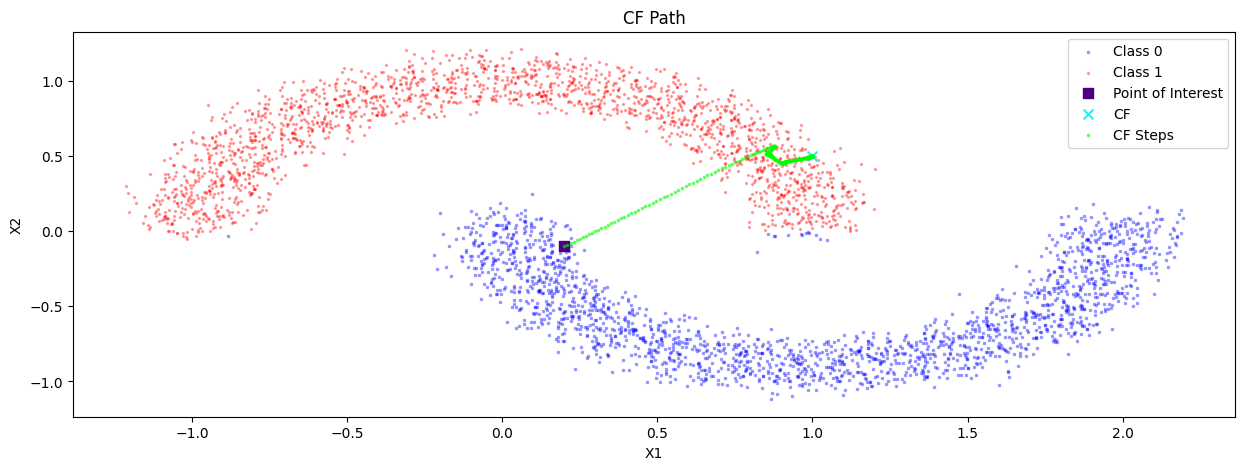

In [43]:
visualize_cf_and_steps(cf_connected,cf_steps_connected, points, y_pred_ensemble_points)

In [44]:
def connectedness_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = epistemic_uncertainty_ensemble(probs_ensemble)


        # Choose as reference point the point with highest probability for this class in the dataset
        probs_reference = ensemble_probs(torch.tensor(points)).mean(dim=0)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(points[idx_reference])



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        eu_line = epistemic_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -target_probs + torch.mean(
            eu_line
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_connected_eu, cf_steps_connected_eu = connectedness_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

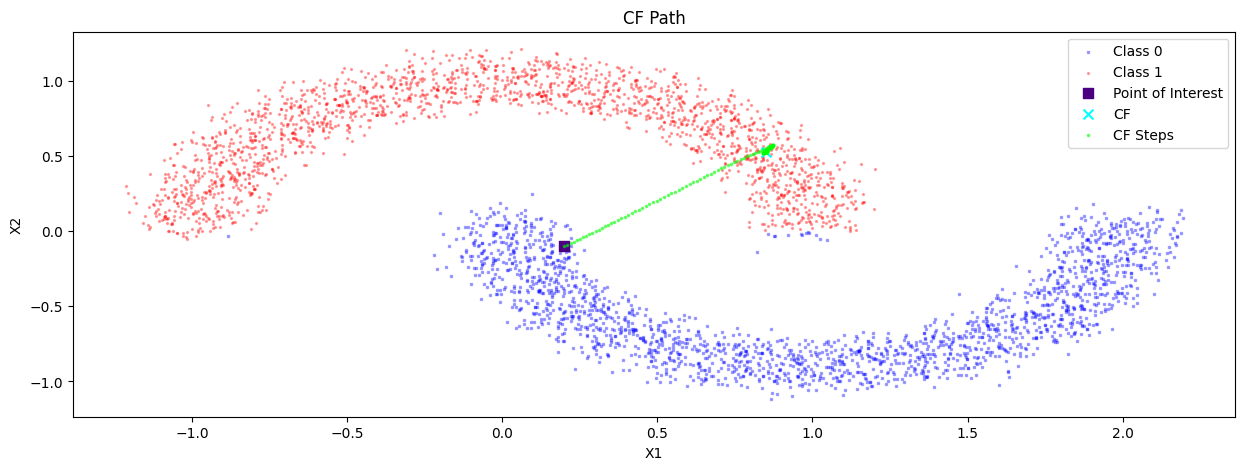

In [45]:
visualize_cf_and_steps(cf_connected_eu,cf_steps_connected_eu, points, y_pred_ensemble_points)

## Similarity

In [46]:
def similiarity_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)



        reference_point = point_to_explain.clone().detach().requires_grad_(True)



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -0.1*target_probs -torch.std(
            au_line
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_similiar, cf_steps_similiar = similiarity_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

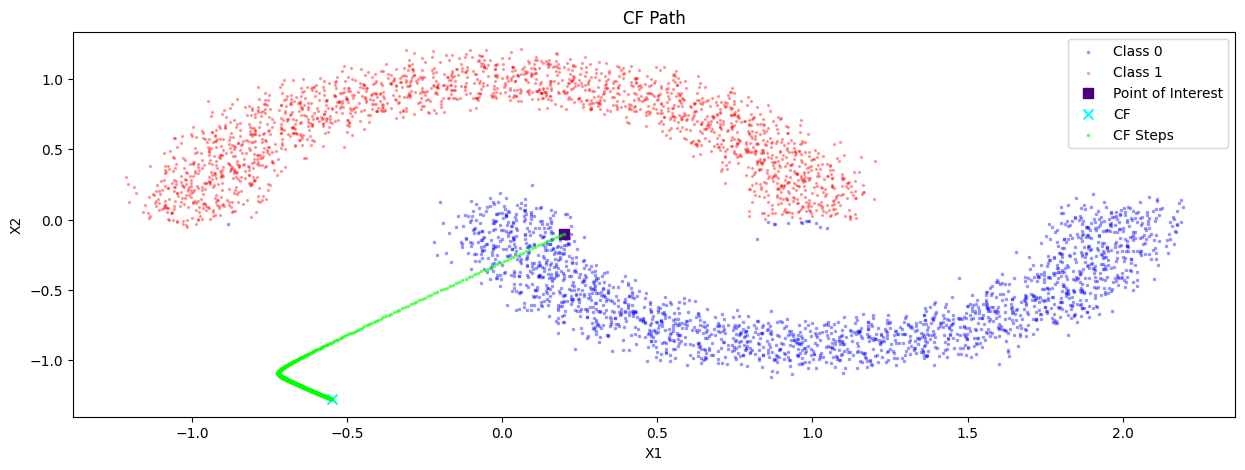

In [47]:
visualize_cf_and_steps(cf_similiar,cf_steps_similiar, points, y_pred_ensemble_points)

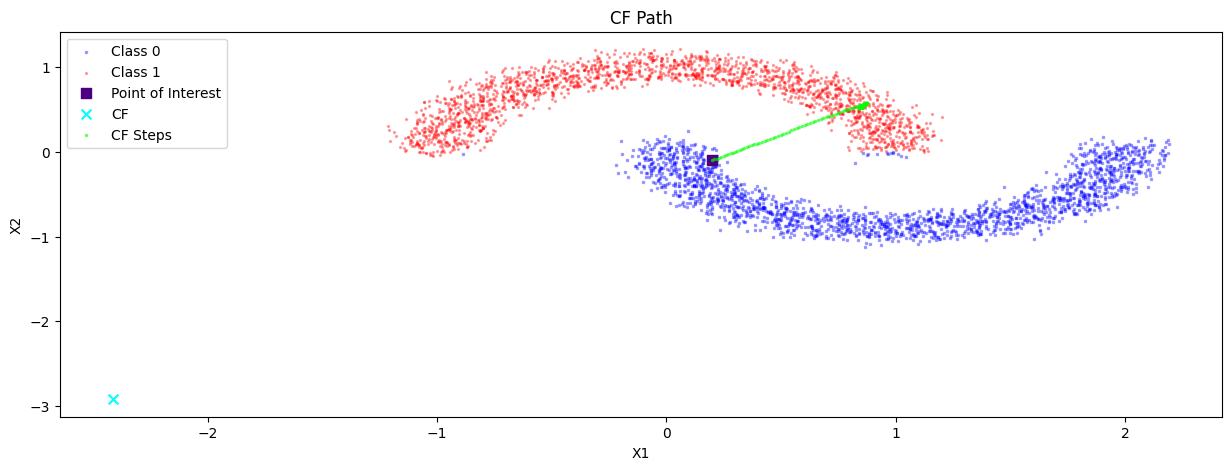

In [48]:
visualize_cf_and_steps(cf_valid,cf_steps_valid, points, y_pred_ensemble_points)

In [49]:
cf_similiar, cf_valid

(tensor([[-0.5493, -1.2767]]), tensor([[-2.4137, -2.9203]]))

In [50]:
print(point_of_interest)

tensor([[ 0.2000, -0.1000]], requires_grad=True)


In [51]:
#l2 distance of similiar and valid
torch.linalg.norm(cf_similiar - point_of_interest, ord=2)

tensor(1.3950, grad_fn=<AmaxBackward0>)

In [52]:
torch.linalg.norm(cf_valid - point_of_interest, ord=2)

tensor(3.8452, grad_fn=<AmaxBackward0>)

## Feasability

In [53]:
def feasability_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)

        # Choose as reference point the point with highest probability for this class in the dataset
        probs_reference = ensemble_probs(torch.tensor(points)).mean(dim=0)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(points[idx_reference])
        #print(reference_point)



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -target_probs + 2*torch.mean(
            au_line
        ) + 1.5*eu
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_feasable, cf_steps_feasable = feasability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

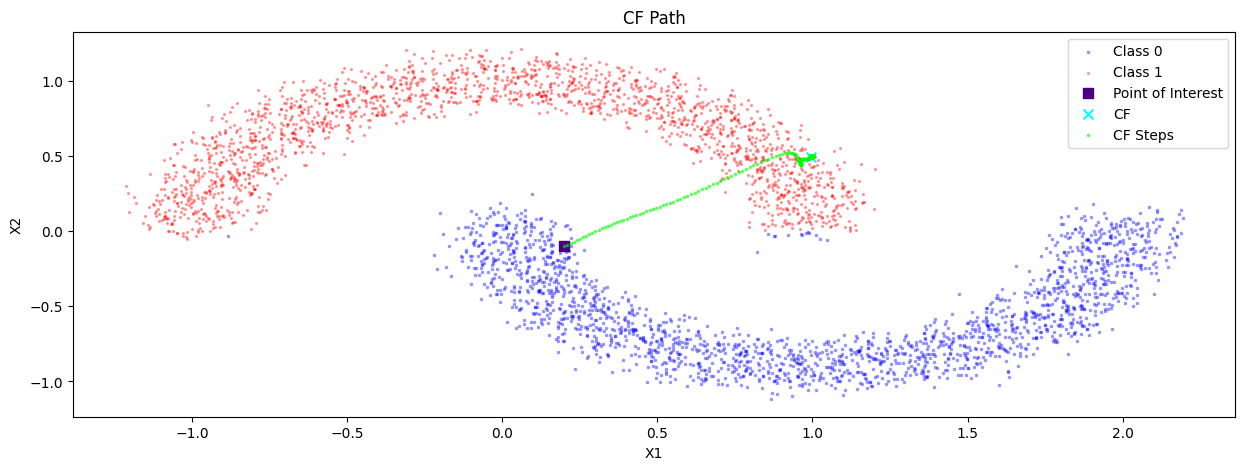

In [54]:
visualize_cf_and_steps(cf_feasable, cf_steps_feasable, points, y_pred_ensemble_points)

In [55]:
cf_feasable, cf_connected

(tensor([[0.9943, 0.4912]]), tensor([[0.9986, 0.4992]]))